In [2]:
# Imports
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

In [3]:
# Load data
data = pd.read_csv('data/Daily_Temp_Data.csv')
original_data = pd.read_csv('data/Original_Data.csv')

# Data Preprocessing
data['date'] = pd.to_datetime(data['date'], format='%d/%m/%Y') # Ensure date is in datetime format

In [4]:
print(original_data.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 403303 entries, 0 to 403302
Data columns (total 28 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   dt                   403303 non-null  int64  
 1   dt_iso               403303 non-null  object 
 2   timezone             403303 non-null  int64  
 3   city_name            403303 non-null  object 
 4   lat                  403303 non-null  float64
 5   lon                  403303 non-null  float64
 6   temp                 403303 non-null  float64
 7   visibility           327860 non-null  float64
 8   dew_point            403303 non-null  float64
 9   feels_like           403303 non-null  float64
 10  temp_min             403303 non-null  float64
 11  temp_max             403303 non-null  float64
 12  pressure             403303 non-null  int64  
 13  sea_level            0 non-null       float64
 14  grnd_level           0 non-null       float64
 15  humidity         

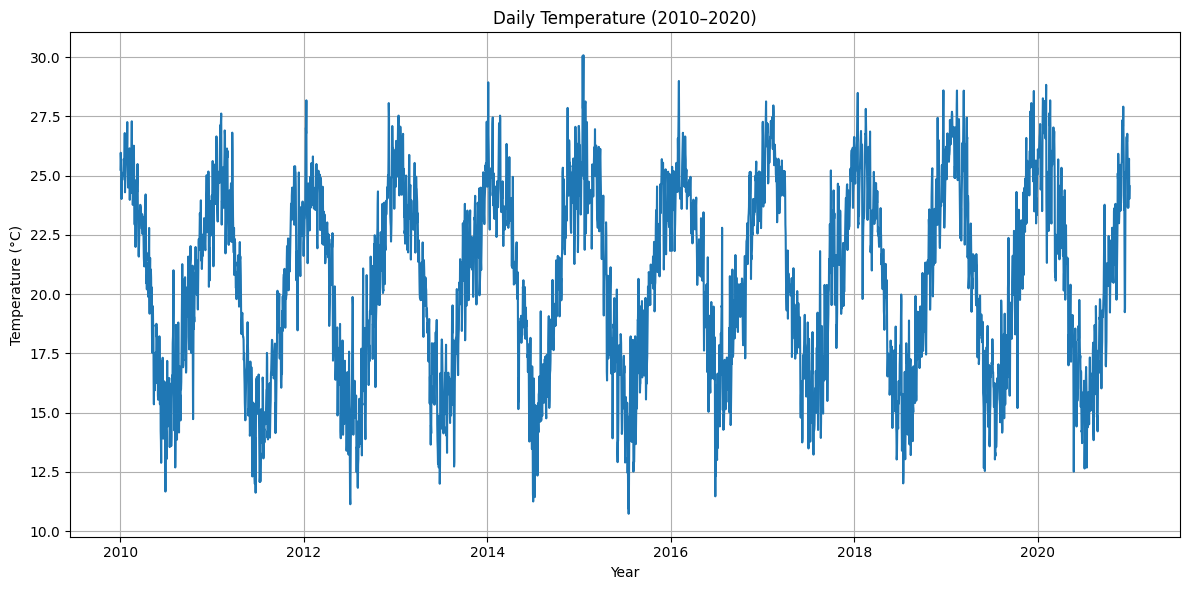

In [5]:
# Convert date to datetime and filter data between 2010-01-01 and 2020-12-31
data['date'] = pd.to_datetime(data['date'], dayfirst=True)
filtered = data[(data['date'] >= '2010-01-01') & (data['date'] <= '2020-12-31')]

# Plot
plt.figure(figsize=(12,6))
plt.plot(filtered['date'], filtered['temp'])
plt.title('Daily Temperature (2010–2020)')
plt.xlabel('Year')
plt.ylabel('Temperature (°C)')
plt.grid(True)
plt.tight_layout()
plt.show()

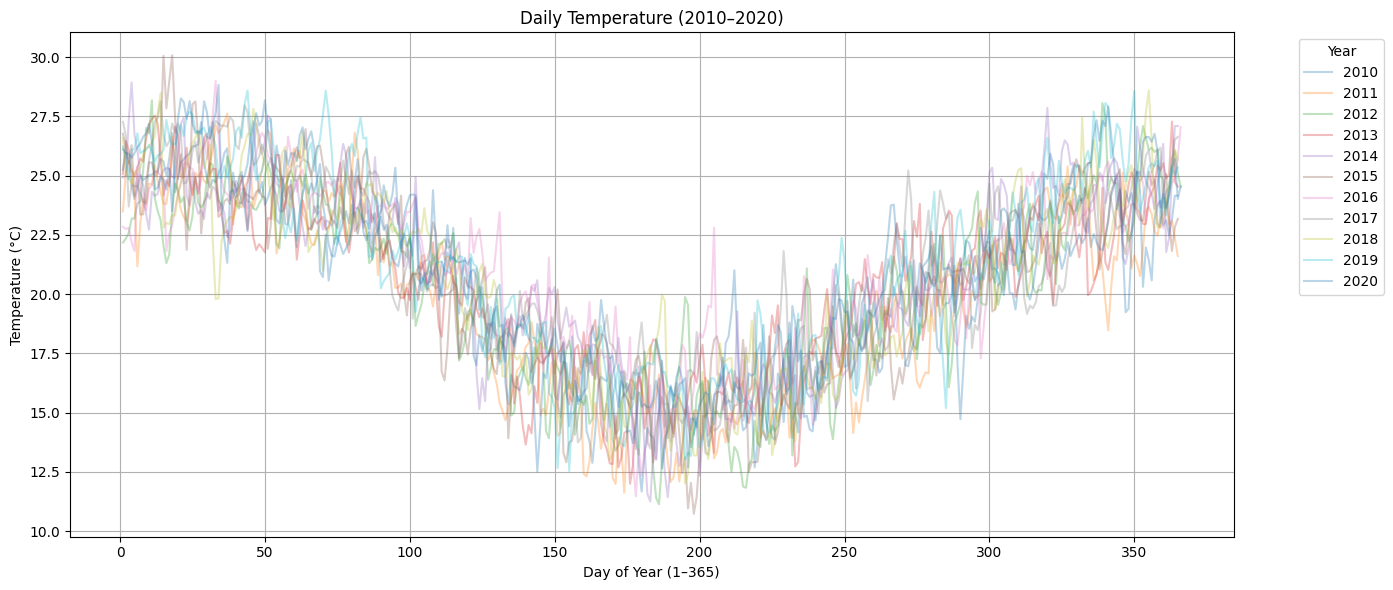

In [6]:
data['date'] = pd.to_datetime(data['date'], dayfirst=True)
data = data[(data['date'] >= '2010-01-01') & (data['date'] <= '2020-12-31')]


plt.figure(figsize=(14, 6))

# Group by year and plot each
for y, d in data.groupby(data['date'].dt.year):
    plt.plot(d['date'].dt.dayofyear, d['temp'], label=str(y), alpha=0.3)

plt.title('Daily Temperature (2010–2020)')
plt.xlabel('Day of Year (1–365)')
plt.ylabel('Temperature (°C)')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()

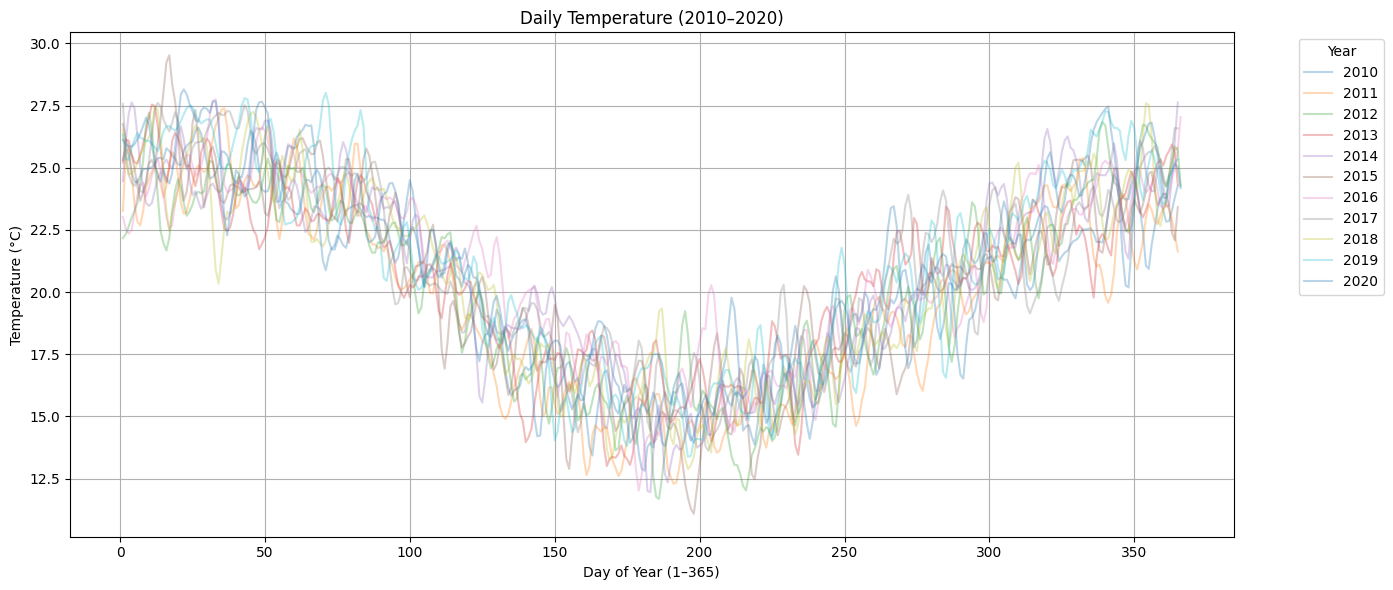

In [18]:
from scipy.signal import savgol_filter

plt.figure(figsize=(14, 6))

for y, d in data.groupby(data['date'].dt.year):
    d = d.sort_values('date')
    smoothed = savgol_filter(d['temp'], window_length=7, polyorder=3)
    plt.plot(d['date'].dt.dayofyear, smoothed, label=str(y), alpha=0.3)

plt.title('Daily Temperature (2010–2020)')
plt.xlabel('Day of Year (1–365)')
plt.ylabel('Temperature (°C)')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()


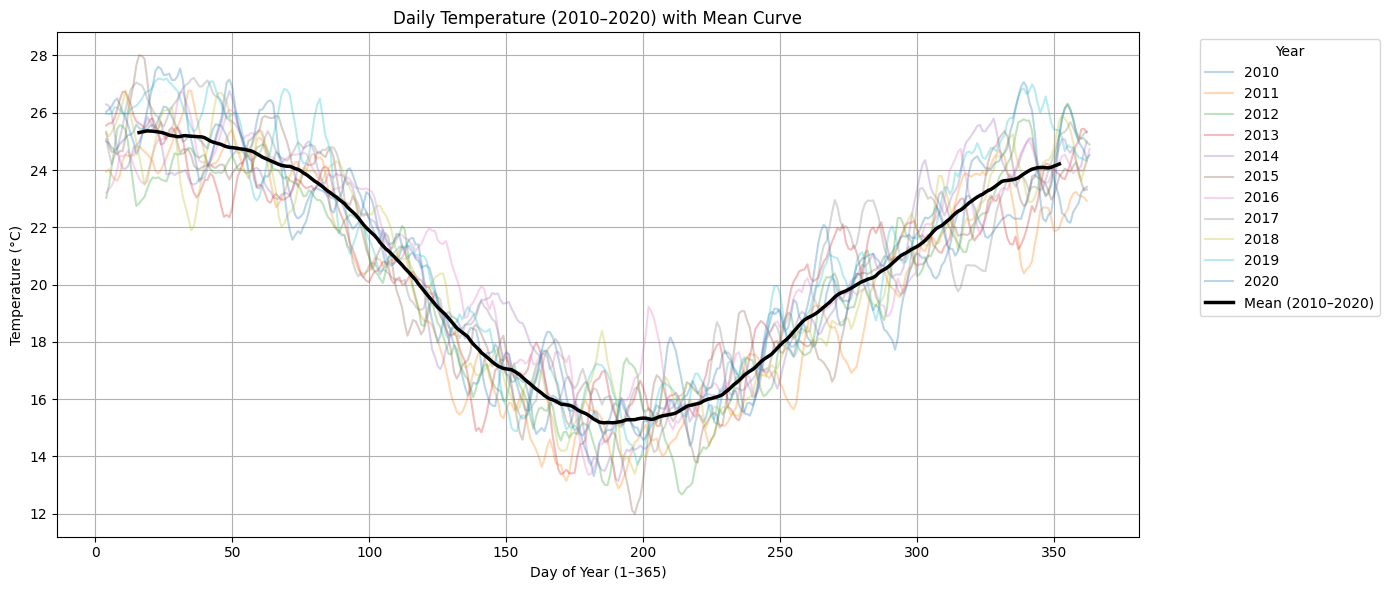

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

data['date'] = pd.to_datetime(data['date'], dayfirst=True)
data = data[(data['date'] >= '2010-01-01') & (data['date'] <= '2020-12-31')]

plt.figure(figsize=(14, 6))

for y, d in data.groupby(data['date'].dt.year):
    d = d.sort_values('date')
    smoothed = d['temp'].rolling(window=7, center=True).mean()
    plt.plot(d['date'].dt.dayofyear, smoothed, label=str(y), alpha=0.3)

data['dayofyear'] = data['date'].dt.dayofyear
mean_curve = data.groupby('dayofyear')['temp'].mean().rolling(window=30, center=True).mean()

# Plot mean curve
plt.plot(mean_curve.index, mean_curve.values, color='black', linewidth=2.5, label='Mean (2010–2020)')

# Labels and layout
plt.title('Daily Temperature (2010–2020) with Mean Curve')
plt.xlabel('Day of Year (1–365)')
plt.ylabel('Temperature (°C)')
plt.legend(title='Year', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True)
plt.tight_layout()
plt.show()
